In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

# 1. Setting up Environment
for folder in ['data', 'visuals']:
    if not os.path.exists(folder): os.makedirs(folder)

np.random.seed(88)
n_weeks = 104 # 2 years of weekly data

# Generating Spend
tiktok_spend = np.random.uniform(10000, 50000, n_weeks)
google_spend = np.random.uniform(20000, 80000, n_weeks)
podcast_spend = np.random.uniform(5000, 20000, n_weeks)

# Generating Sales with diminishing returns (using Log) and some seasonality
base_sales = 50000
sales = (base_sales + 
         (8 * np.log(tiktok_spend) * 1000) +   # TikTok: High impact
         (5 * np.log(google_spend) * 1000) +   # Google: Steady impact
         (2 * np.log(podcast_spend) * 1000) +  # Podcast: Low impact
         np.random.normal(0, 5000, n_weeks))    # Noise

marketing_data = pd.DataFrame({
    'week': range(1, n_weeks + 1),
    'tiktok_spend': tiktok_spend,
    'google_spend': google_spend,
    'podcast_spend': podcast_spend,
    'sales': sales
})

# EXPORTING DATA & VISUALS
marketing_data.to_csv('data/marketing_spend_data.csv', index=False)
print(marketing_data.head())

   week  tiktok_spend  google_spend  podcast_spend          sales
0     1  35902.041974  76160.146000    6719.054537  203120.963229
1     2  30285.987529  31968.487338   11316.837491  205218.916588
2     3  31133.655206  57428.063334   14809.558017  215370.192701
3     4  45851.408160  29430.325150    8712.420616  198253.077202
4     5  37999.647627  24953.675136   15790.044256  198235.918721


In [2]:
if not os.path.exists('visuals'):
    os.makedirs('visuals')

# Defining features (Spend) and target (Sales)
X = marketing_data[['tiktok_spend', 'google_spend', 'podcast_spend']]
y = marketing_data['sales']

# Adding a constant for the intercept
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

plt.savefig('visuals/channel_roi_comparison.png', dpi=300, bbox_inches='tight')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     21.87
Date:                Sun, 25 Jan 2026   Prob (F-statistic):           5.71e-11
Time:                        02:34:33   Log-Likelihood:                -1039.1
No. Observations:                 104   AIC:                             2086.
Df Residuals:                     100   BIC:                             2097.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.846e+05   2632.609     70.121

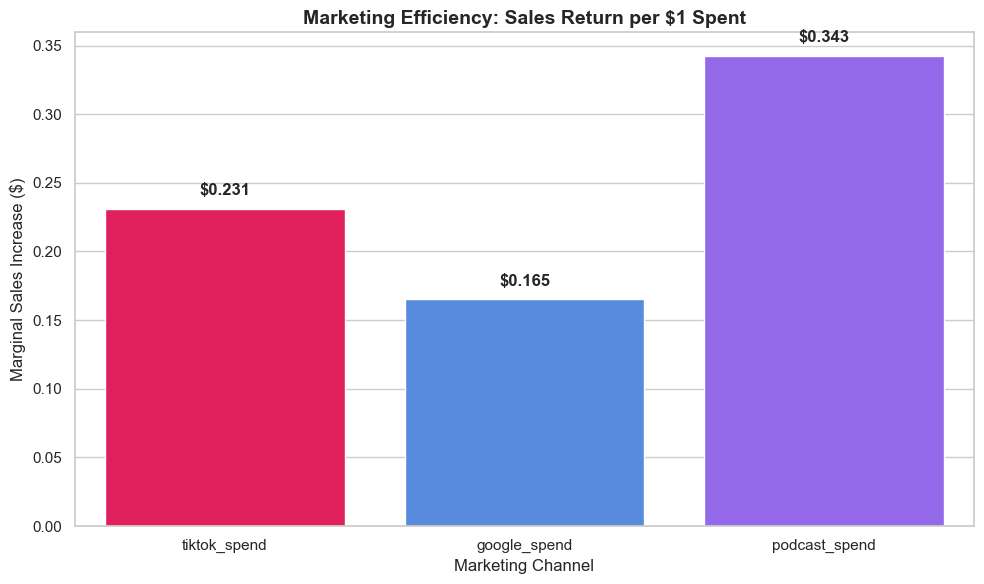

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the style is set
sns.set_theme(style="whitegrid")

# 1. Preparing the data from the OLS model
# model.params[1:] gets the coefficients for TikTok, Google, and Podcasts
roi_stats = model.params[1:]
roi_df = pd.DataFrame({
    'Channel': roi_stats.index,
    'Coefficient': roi_stats.values
})

# 2. Create the Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Channel', 
    y='Coefficient', 
    data=roi_df, 
    hue='Channel',    
    palette=['#ff0050', '#4285F4', '#8c52ff'], # Brand colors for TikTok, Google, Podcasts
    legend=False      
)

# 3. Adding a "Baseline" line or labels
plt.title('Marketing Efficiency: Sales Return per $1 Spent', fontsize=14, fontweight='bold')
plt.ylabel('Marginal Sales Increase ($)')
plt.xlabel('Marketing Channel')

# Adding data labels on top of the bars for clarity
for i, v in enumerate(roi_df['Coefficient']):
    plt.text(i, v + 0.01, f'${v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/channel_roi_comparison.png', dpi=300, bbox_inches='tight')
plt.show()